In [239]:
import json
import matplotlib.pyplot as plt
import numpy as np
import math
import matplotlib as mpl

In [240]:
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['font.size'] = 25  # 设置字体大小
# plt.rcParams.update({
#     "text.usetex": True,          # 启用LaTeX渲染
#     # "font.family": "serif",       # 使用衬线字体（与LaTeX风格一致）
#     "text.latex.preamble": r"\usepackage{amsmath}"  # 添加amsmath包
# })

In [241]:
colors = ['#66BC98', '#AAD09D', '#E3EA96', '#FCDC89', '#E26844', '#8A233F', '#C2ABC8']
colors = ['#66BC98', '#AAD09D', '#E3EA96', '#FCDC89', '#E26844', '#8A233F', '#C2ABC8']
colors = ["#89c8e8","#caa2f4","#1f78b4","#6a3d9a","#8acc72", "#ebd57c", "#ed4437", "#fc9a9a"]
colors = ["#E63946","#F1FAEE","#A8DADC","#457B9D","#1D3557"]
# from palettable.colorbrewer.qualitative import Set3_8
# colors = Set3_8.hex_colors
from palettable.cartocolors.qualitative import Safe_3
colors = Safe_3.hex_colors

science_colors = ['#005F73', '#0A9396', '#94D2BD', '#E9D8A6',
                 '#EE9B00', '#CA6702', '#BB3E03', '#AE2012']
nature_colors = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728', 
                '#9467BD', '#8C564B', '#E377C2', '#7F7F7F']
colors = nature_colors

# colors = ['#52d1dc', '#d4e09b', '#80917f', '#2b4162', '#d5896f', '#dea9a6', '#e7c8dd']
tag = ['Zip', 'Random', 'Cluster', 'Perplexity', 'Deita', 'SuperFiltering']
markers = ['o', 's', 'D', '^', 'p', '*']
backbone_list = ['Llama-3-8B', 'Mistral-7B', 'Gemma2-9B']

In [242]:
mt_bench = {
    'Llama-3-8B': [[7.25, 7.13, 7.15, 7.04, 7.06, 6.55], [0.03, 0.03, 0.02, 0.05, 0.03, 0.04]],
    'Mistral-7B': [[7.08, 6.98, 6.63, 6.81, 6.75, 6.15], [0.032, 0.03, 0.04, 0.045, 0.06, 0.05]],
    'Gemma2-9B': [[7.35, 7.27, 7.25, 7.18, 7.22, 6.97], [0.02, 0.026, 0.03, 0.029, 0.026, 0.042]],
}

compression_ratio = {
    'Llama-3-8B': [2.45, 3.29, 3.296, 3.30, 3.51, 4.95],
    'Mistral-7B': [2.45, 3.27, 3.28, 3.285, 3.47, 4.79],
    'Gemma2-9B': [2.45, 3.49, 3.55, 3.54, 4.42, 5.20],
}

first_epoch_loss = {
    'Llama-3-8B': [[1.04, 0.8987, 0.9064, 0.8784, 0.7922, 0.6298], [0.02, 0.018, 0.028, 0.015, 0.019, 0.017]],
    'Mistral-7B': [[0.8515, 0.75, 0.73, 0.74, 0.62, 0.48], [0.017, 0.016, 0.023, 0.029, 0.015, 0.023]],
    'Gemma2-9B': [[0.9873, 0.8368, 0.8385, 0.8368, 0.76, 0.50], [0.021, 0.019, 0.016, 0.021, 0.020, 0.018]],
}

In [243]:
def plot_with_curve(ax, x, y, xlabel, ylabel, title=None, index=0, corr_shift=1):
    mean, var = y
    x_fit = np.linspace(min(x), max(x), 100)
    corr_coef = np.corrcoef(x, mean)[0, 1]
    print(corr_coef)
    
    # fit mean value
    coefficients = np.polyfit(x, mean, 2)
    p = np.poly1d(coefficients)
    y_fit = p(x_fit)
    ax.plot(x_fit, y_fit, color=colors[index], linestyle='--', label=f"R = {corr_coef:.2f}")

    # fit variance value
    y_max = [mean[i] + var[i] for i in range(len(mean))]
    coefficients = np.polyfit(x, y_max, 2)
    p = np.poly1d(coefficients)
    y_fit_max = p(x_fit)

    y_min = [mean[i] - var[i] for i in range(len(mean))]
    coefficients = np.polyfit(x, y_min, 2)
    p = np.poly1d(coefficients)
    y_fit_min = p(x_fit)
    ax.fill_between(x_fit, y_fit_min, y_fit_max, color=colors[index], linestyle='--', alpha=0.2)  

    # Plot the original data points with different colors for each point
    for xi, yi, marker, point_tag in zip(x, mean, markers, tag):
        ax.scatter(xi, yi, color=colors[index], marker=marker, s=42)

    # Add correlation coefficient text to the plot
    # x_text = (min(x) + max(x)) * 0.65  # Place the text at the middle of x range
    # y_text = p(x_text) * corr_shift  # Slightly above the max y value
    # ax.text(x_text, y_text, f"R = {corr_coef:.2f}", color=colors[index], fontsize=14, ha='center')

    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.spines['right'].set_visible(False)  # 隐藏右边框
    ax.spines['top'].set_visible(False)    # 隐藏上边框
    # ax.set_title(title)
    ax.legend(fontsize=14, loc='lower left')

def plot_line(ax, x, y, xlabel, ylabel, title=None, index=0):
    mean, var = np.array(y[0]), np.array(y[1])
    # Plot the original data points with different colors for each point
    for xi, yi, marker, point_tag in zip(x, mean, markers, tag):
        ax.scatter(xi, yi, color=colors[index], marker=marker, s=42)
    ax.fill_between(x, mean - var, mean + var, color=colors[index], linestyle='--', alpha=0.2)  

    ax.plot(x, mean, color=colors[index], linestyle='-')
    # ax.fill_between(x, mean - var, mean + var, color=colors[index], linestyle='--')

    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.spines['right'].set_visible(False)  # 隐藏右边框
    ax.spines['top'].set_visible(False)    # 隐藏上边框
    # ax.set_title(title)

def plot_errorbar(ax, x, mean, var, index=0):
    ax.errorbar(
        x, 
        mean,
        yerr=var,
        color=colors[index],
        fmt='none',
        capsize=3,
        alpha=0.5
    )

In [244]:
def plot_r_z_curve(ax, title):
    for idx, backbone in enumerate(backbone_list):
        # Plot error bars for each point
        for i in range(len(compression_ratio[backbone])):
            plot_errorbar(
                ax,
                compression_ratio[backbone][i],
                mt_bench[backbone][0][i],
                mt_bench[backbone][1][i],
                idx
            )
        
        plot_with_curve(
            ax,
            compression_ratio[backbone],
            mt_bench[backbone],
            'Compression ratio',
            'Model performance',
            title,
            idx,
            1.03
        )

In [245]:

# def plot_loss_curve(ax, title):
#     for idx, backbone in enumerate(backbone_list):
#         # Plot error bars for each point
#         for i in range(len(compression_ratio[backbone])):
#             plot_errorbar(
#                 ax,
#                 first_epoch_loss[backbone][0][i],
#                 mt_bench[backbone][0][i],
#                 mt_bench[backbone][1][i],
#                 idx
#             )
#         plot_with_curve(
#             ax,
#             first_epoch_loss[backbone][0],
#             mt_bench[backbone][0],
#             'Eerly training loss',
#             'Model performance',
#             title,
#             idx
#         )

In [246]:

def plot_r_l_curve(ax, title):
    for idx, backbone in enumerate(backbone_list):
        # Plot error bars for each point
        for i in range(len(compression_ratio[backbone])):
            plot_errorbar(
                ax,
                compression_ratio[backbone][i],
                first_epoch_loss[backbone][0][i],
                first_epoch_loss[backbone][1][i],
                idx
            )
        plot_with_curve(
            ax,
            compression_ratio[backbone],
            first_epoch_loss[backbone],
            'Compression ratio',
            'Eerly training loss',
            title,
            idx,
            1.2
        )

In [257]:
from PIL import Image

def plot_application(ax, title):
    def y_fit_func(x):
        return -0.5 * x + 8
    x_fit = np.linspace(0.5, 10.5, 100)
    y_fit = y_fit_func(x_fit)
    ax.plot(x_fit, y_fit, color='Grey', linestyle='dotted') # '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'
    
    x = np.array([1, 2, 5, 10])
    y = y_fit_func(x) + np.array([-0.1, -0.15, 0.24, -0.12])
    ax.scatter(x, y, color='Grey')

    x_text = 1  # Place the text at the middle of x range
    y_text = y_fit_func(x_text) - 0.1  # Slightly above the max y value
    ax.text(x_text - 0.5, y_text - 0.1, f"x4", color='Black', ha='center')

    x_text = 2  # Place the text at the middle of x range
    y_text = y_fit_func(x_text) - 0.15 # Slightly above the max y value
    ax.text(x_text - 0.5, y_text - 0.1, f"x3", color='Black', ha='center')

    x_text = 5  # Place the text at the middle of x range
    y_text = y_fit_func(x_text) + 0.24  # Slightly above the max y value
    ax.text(x_text + 0.5, y_text - 0.1, f"x2", color='Black', ha='center')

    x_text = 10  # Place the text at the middle of x range
    y_text = y_fit_func(x_text) - 0.12  # Slightly above the max y value
    ax.text(x_text - 0.5, y_text - 0.1, f"x1", color='Black', ha='center')

    x = np.array([2.3])
    y = y_fit_func(x) + np.array([1.1])
    ax.scatter(x, y, color=colors[1])

    x_text = 2.3  # Place the text at the middle of x range
    y_text = y_fit_func(x_text) + 1.1  # Slightly above the max y value
    ax.text(x_text + 0.5, y_text - 0.1, f"x5", color=colors[1], ha='center')

    ax.annotate('', xy=(2.3, y_fit_func(2.3) + 0.05), xytext=(2.3, y_fit_func(2.3) + 1.05),
        arrowprops=dict(arrowstyle='<->,head_length=0.15,head_width=0.15', lw=1.5, color=colors[1], mutation_scale=15),)
    
    x_text = 0.5  # Place the text at the middle of x range
    y_text = 4  # Slightly above the max y value
    ax.text(x_text, y_text, f"Performance:", color='Black', ha='left')
    performance_text = 'x4 > x3 > x5 > x2 > x1'
    performance_text_colors = ['Black' for _ in range(10)] + [colors[1] for _ in range(2)] + ['Black' for _ in range(10)]
    for idx, _ in enumerate(performance_text):
        ax.text(x_text, y_text - 0.5, _, color=performance_text_colors[idx], ha='left')
        x_text += 0.35

    # ax.imshow(Image.open('entropy_law_application.png'))
    # ax.axis('off')
    # ax.set_aspect('auto')
    ax.set_xticks([])
    ax.set_yticks([])
    # ax.autoscale(enable=True, tight=True)
    ax.set_ylabel("Early Training Loss")
    ax.set_xlabel("Compression Ratio")
    ax.spines['right'].set_visible(False)  # 隐藏右边框
    ax.spines['top'].set_visible(False)    # 隐藏上边框
    # ax.set_title(title)

In [258]:
mt_bench_perturbation = {
    'Llama-3-8B': [[7.25, 6.82, 6.77, 6.65, 4.38], [0.02, 0.045, 0.044, 0.040, 0.049]],
    'Mistral-7B': [[7.08, 5.68, 5.50, 5.22, 1.75], [0.03, 0.035, 0.042, 0.045, 0.041]],
    'Gemma2-9B': [[7.35, 7.02, 6.89, 6.64, 5.23], [0.023, 0.035, 0.045, 0.040, 0.042]],
}
def plot_quality_curve(ax, title):
    x = ['0%', '25%', '50%', '75%', '100%']
    for idx, backbone in enumerate(backbone_list):
        for i in range(len(mt_bench_perturbation[backbone])):
            plot_errorbar(
                ax,
                x[i],
                mt_bench_perturbation[backbone][0][i],
                mt_bench_perturbation[backbone][1][i],
                idx
            )
        plot_line(
            ax,
            x,
            mt_bench_perturbation[backbone],
            'Perturbation ratio',
            'Model performance',
            title,
            idx
        )

In [259]:
mt_bench_zip_ratio = {
    'Llama-3-8B': [[7.25, 7.03, 6.75, 6.45], [0.023, 0.029, 0.037, 0.035]],
    'Mistral-7B': [[7.08, 6.5, 6.30, 6.03], [0.022, 0.024, 0.031, 0.034]],
    'Gemma2-9B': [[7.35, 7.18, 6.91, 6.62], [0.023, 0.032, 0.035, 0.015]],
}
def plot_random_ratio_curve(ax, title):
    x = ['0%', '25%', '50%', '75%']
    for idx, backbone in enumerate(backbone_list):
        for i in range(len(mt_bench_zip_ratio[backbone])):
            plot_errorbar(
                ax,
                x[i],
                mt_bench_zip_ratio[backbone][0][i],
                mt_bench_zip_ratio[backbone][1][i],
                idx
            )
        plot_line(
            ax,
            x,
            mt_bench_zip_ratio[backbone],
            'Random data ratio',
            'Model performance',
            title,
            idx
        )

-0.9688062596372488
-0.9377136372307454
-0.8930272149868351
-0.9757254187795446
-0.9620866909295785
-0.9632117009505843


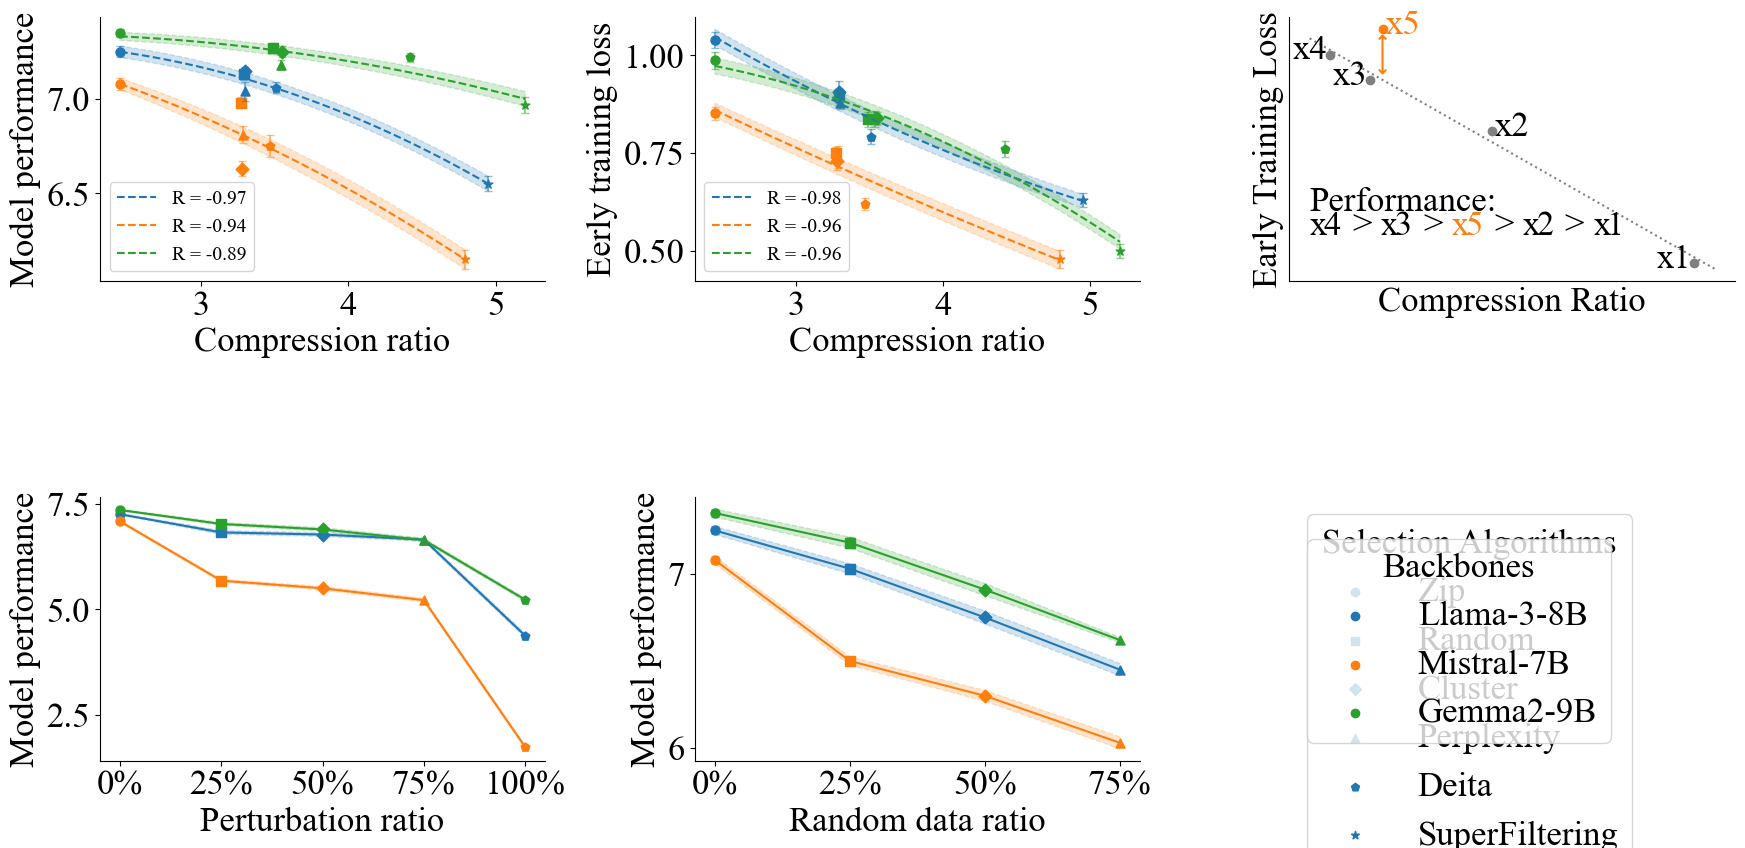

In [260]:

fig, axs = plt.subplots(2, 3, figsize=(18, 9))
axs[1, 2].axis('off')
plot_r_z_curve(axs[0, 0], title='R-Z curve')
plot_r_l_curve(axs[0, 1], title='R-L curve')
plot_application(axs[0, 2], title='Real-world application')
plot_quality_curve(axs[1, 0], title='Perturbation curve')
plot_random_ratio_curve(axs[1, 1], title='Random ratio curve')
# plot_bars(axs[1, 0], rst_dict1, title='MT-bench results', lengend=True)
# plot_bars(axs[1, 1], rst_dict2, title='GSM-8K', min_ratio=0.65)
# plot_bars(axs[0, 0], rst_dict3, title='CSL results')
# plot_bars(axs[0, 1], rst_dict4, title='HSR results')
# plot_bars(axs[0, 2], rst_dict5, title='SSR results')
fig.tight_layout(h_pad=4)

data_for_lengend1, data_for_lengend2 = [], []
for i, tag_ in enumerate(tag):
    rst = plt.scatter([], [], color=colors[0], marker=markers[i], label=f'{tag_}')
    data_for_lengend1.append(rst)
for i, backbone in enumerate(backbone_list):
    rst = plt.scatter([], [], color=colors[i], marker=markers[0], label=f'{backbone}')
    data_for_lengend2.append(rst)

lengend1 = plt.legend(data_for_lengend1, tag, title='Selection Algorithms', loc='upper left')
plt.legend(data_for_lengend2, backbone_list, title='Backbones', loc='lower left')
plt.gca().add_artist(lengend1)

plt.savefig(f"/zhdd/home/mjyin/Projects/axolotl/figure/entropy-law/all_curves.pdf", format='pdf', dpi=1000, bbox_inches='tight', transparent=True)
plt.show()

-0.9688062596372488
-0.9377136372307454
-0.8930272149868351
-0.9757254187795446
-0.9620866909295785
-0.9632117009505843


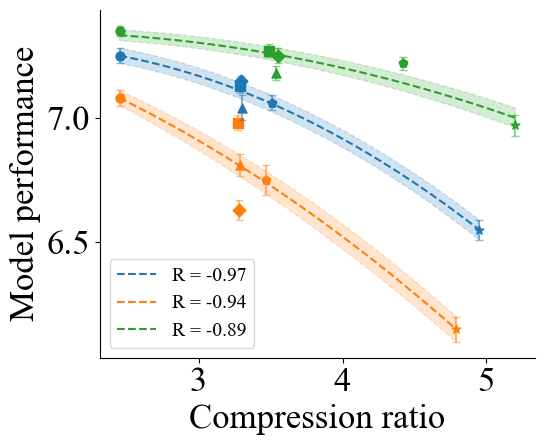

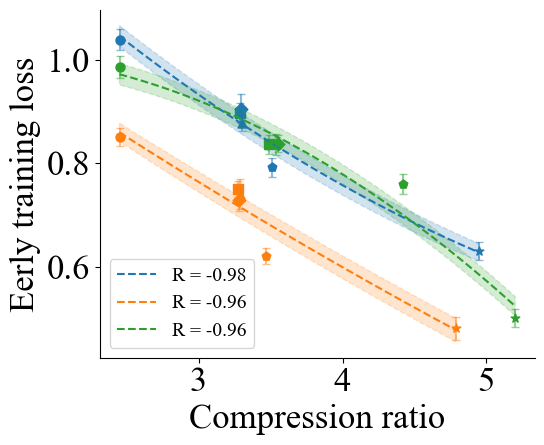

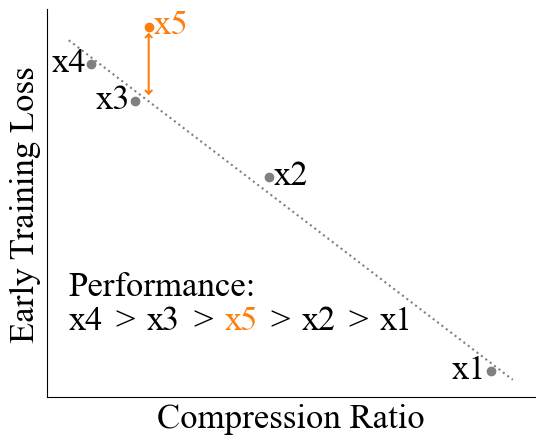

In [261]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_r_z_curve(ax, title='R-K curve')
plt.tight_layout()
plt.savefig(f"/zhdd/home/mjyin/Projects/axolotl/figure/extended/all_curves/rk.pdf", format='pdf', dpi=1000, bbox_inches='tight', transparent=True)

fig, ax = plt.subplots(figsize=(6, 5))
plot_r_l_curve(ax, title='R-L curve')
plt.tight_layout()
plt.savefig(f"/zhdd/home/mjyin/Projects/axolotl/figure/extended/all_curves/rl.pdf", format='pdf', dpi=1000, bbox_inches='tight', transparent=True)

fig, ax = plt.subplots(figsize=(6, 5))
plot_application(ax, title='Real-world application')
plt.tight_layout()
plt.savefig(f"/zhdd/home/mjyin/Projects/axolotl/figure/extended/all_curves/real-world.pdf", format='pdf', dpi=1000, bbox_inches='tight', transparent=True)

# fig, ax = plt.subplots(figsize=(5, 4))
# plot_quality_curve(ax, title='Perturbation curve')
# plt.tight_layout()
# plt.savefig(f"/zhdd/home/mjyin/Projects/axolotl/figure/extended/all_curves/perturbation.pdf", format='pdf', dpi=1000, bbox_inches='tight', transparent=True)

# fig, ax = plt.subplots(figsize=(5, 4))
# plot_random_ratio_curve(ax, title='Random ratio curve')
# plt.tight_layout()
# plt.savefig(f"/zhdd/home/mjyin/Projects/axolotl/figure/extended/all_curves/noise.pdf", format='pdf', dpi=1000, bbox_inches='tight', transparent=True)

